<a href="https://colab.research.google.com/github/GULLOJUUDAYKIRAN5/2-year-c-programs/blob/main/VIRTUSA__PYTHON_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Smart Expense Tracker**

REQURIED MODULES

In [2]:
import json
from datetime import datetime
import matplotlib.pyplot as plt
FILE_NAME = ""

USER CREATION


In [5]:
def select_user():
    print("\n1. New User")
    print("2. Existing User")
    choice = input("Enter choice: ")
    if choice == "1":
        username = input("Enter new username: ")
        print("User created!")
        return username
    elif choice == "2":
        username = input("Enter username: ")
        return username
    else:
        print("Invalid choice")
        return select_user()

Load Data

In [6]:
def load_data():
    try:
        file = open(FILE_NAME, "r")
        data = json.load(file)
        file.close()
        return data
    except:
        return []

Save Data

In [7]:
def save_data(data):
    file = open(FILE_NAME, "w")
    json.dump(data, file, indent=4)
    file.close()


Add Expense

In [8]:
def add_expense():
    data = load_data()
    date = input("Enter date (YYYY-MM-DD) or press Enter for today: ")
    if date == "":
        date = datetime.today().strftime("%Y-%m-%d")
    category = input("Enter category (Food/Travel/Bills): ")
    try:
        amount = float(input("Enter amount: "))
    except:
        print("Invalid amount!")
        return
    description = input("Enter description: ")
    expense = {
        "date": date,
        "category": category,
        "amount": amount,
        "description": description
    }
    data.append(expense)
    save_data(data)
    print("Expense added successfully!")


Monthly Summary

In [9]:
def monthly_summary():
    data = load_data()
    month = input("Enter month (YYYY-MM): ")
    total = 0
    category_total = {}
    for exp in data:
        if exp["date"].startswith(month):
            total = total + exp["amount"]
            cat = exp["category"]
            if cat in category_total:
                category_total[cat] = category_total[cat] + exp["amount"]
            else:
                category_total[cat] = exp["amount"]
    print("\nSummary for", month)
    print("Total Spending:", total)
    for cat in category_total:
        print(cat, ":", category_total[cat])

    return category_total


Pie Chart

In [4]:
def show_pie_chart():
    category_total = monthly_summary()
    if len(category_total) == 0:
        print("No data to show")
        return
    labels = []
    values = []
    for cat in category_total:
        labels.append(cat)
        values.append(category_total[cat])
    plt.pie(values, labels=labels, autopct="%1.1f%%")
    plt.title("Expenses by Category")
    plt.show()

Insights

In [10]:
def show_insights():
    data = load_data()
    category_total = {}
    for exp in data:
        cat = exp["category"]
        if cat in category_total:
            category_total[cat] = category_total[cat] + exp["amount"]
        else:
            category_total[cat] = exp["amount"]
    if len(category_total) == 0:
        print("No data available")
        return
    highest_category = ""
    highest_amount = 0
    for cat in category_total:
        if category_total[cat] > highest_amount:
            highest_amount = category_total[cat]
            highest_category = cat
    print("\nInsights:")
    print("Highest spending category:", highest_category)
    if highest_category.lower() == "food":
        print("Try reducing food expenses")
    elif highest_category.lower() == "travel":
        print("Use public transport")
    elif highest_category.lower() == "bills":
        print("Check subscriptions")
    else:
        print("Control spending in this category")


Main Menu


1. New User
2. Existing User
Enter choice: 1
Enter new username: uday
User created!
Welcome, uday

==== Expense Tracker ====
1. Add Expense
2. Monthly Summary
3. Show Pie Chart
4. Show Insights
5. Exit
Enter choice: 1
Enter date (YYYY-MM-DD) or press Enter for today: 2023-10-30
Enter category (Food/Travel/Bills): TRAVEL
Enter amount: 3000
Enter description: TRIP
Expense added successfully!

==== Expense Tracker ====
1. Add Expense
2. Monthly Summary
3. Show Pie Chart
4. Show Insights
5. Exit
Enter choice: 3
Enter month (YYYY-MM): 2023-10

Summary for 2023-10
Total Spending: 3035.0
Food : 35.0
TRAVEL : 3000.0


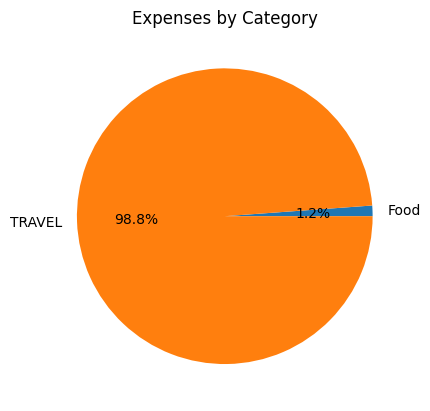


==== Expense Tracker ====
1. Add Expense
2. Monthly Summary
3. Show Pie Chart
4. Show Insights
5. Exit
Enter choice: 5
Goodbye!


In [13]:

global FILE_NAME

username = select_user()
FILE_NAME = username + ".json"

print("Welcome,", username)

while True:
    print("\n==== Expense Tracker ====")
    print("1. Add Expense")
    print("2. Monthly Summary")
    print("3. Show Pie Chart")
    print("4. Show Insights")
    print("5. Exit")

    choice = input("Enter choice: ")

    if choice == "1":
        add_expense()
    elif choice == "2":
        monthly_summary()
    elif choice == "3":
        show_pie_chart()
    elif choice == "4":
        show_insights()
    elif choice == "5":
        print("Goodbye!")
        break
    else:
        print("Invalid choice")


# if __name__ == "__main__":
#     main()